In [1]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from sphWarpCore import radiusSearchCompactHashMap, sphOperation_warp
from sphWarpCore.enumTypes import *

# from diffSPH.neighborhood import buildNeighborhood
# from diffSPH.operations import SPHOperation
# from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
# from diffSPH.operations import KernelCorrectionScheme
# from diffSPH.kernels import *
# from diffSPH.plotting import visualizeParticles
# from diffSPH.kernels import getSPHKernelv2

import matplotlib.pyplot as plt
from demo_util import *

from sphWarpCore.util import generateNeighborTestData
from sphWarpCore import *

Warp DeprecationWarning: warp.config.verbose is deprecated; use warp.config.log_level = warp.LOG_DEBUG instead.


Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/veldora/.cache/warp/1.15.0


TypeError: unsupported callable

In [2]:
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 128
dim = 2
jitter = 0.1
numParticles = nx**dim

warpOnly = False
periodic = True

positions, supports, _, domain, dx = generateNeighborTestData(
        nx, targetNumNeighbors, dim, periodic, device
)

positions = positions + jitter * dx * (torch.rand_like(positions) - 0.5)
masses = torch.full((positions.shape[0],), dx ** dim, device=device, dtype=positions.dtype)
kinds = torch.zeros(positions.shape[0], device=device, dtype=torch.int32)

particles = ParticleState(
        positions=positions.contiguous(),
        supports=supports.contiguous(),
        masses=masses.contiguous(),
        densities=None,
        kinds=kinds,
)

adjacency = radiusSearchCompactHashMap(
        particles,
        domain,
        mode=SupportScheme.SuperSymmetric,
)

densities = warpOperation(
        particles,
        OperationProperties(
                kernel=KernelFunctions.Wendland2,
                operation=WarpOperation.Density,
                supportMode=SupportScheme.Gather,
                operationMode=OperationDirection.AllToAll,
        ),
        domain,
        adjacency=adjacency,
)
particles.densities = densities

# print(domain)

/home/veldora/dev/warpSPHCore/src/sphWarpCore/radiusSearch/wp_compactHash.py:1122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  periodicity = torch.tensor(domain.periodic if domain.periodic is not None else [False] * queryParticles.positions.shape[1], device=queryParticles.positions.device)


Module sphWarpCore.radiusSearch.wp_compactHash a87b46c load on device 'cuda:0' took 9.19 ms  (cached)
Module sphWarpCore.operations.wp_density 39c6d71 load on device 'cuda:0' took 3.57 ms  (cached)


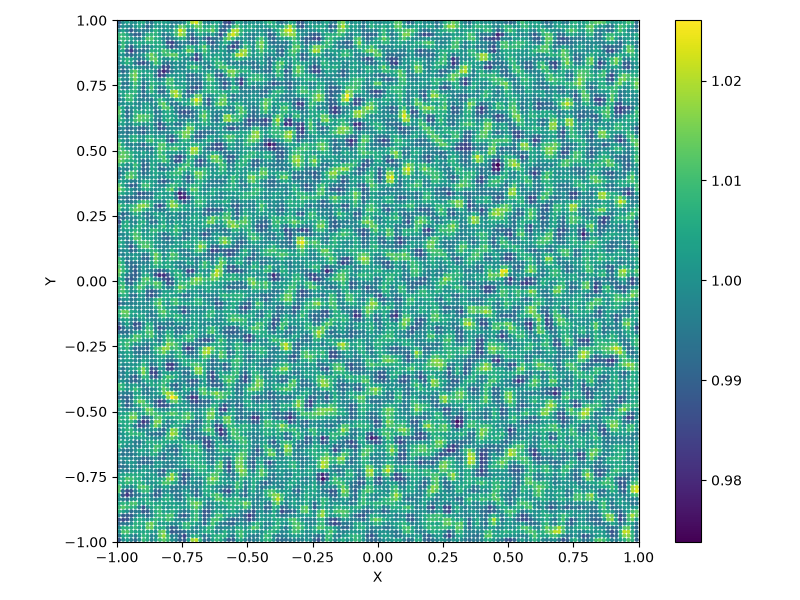

In [6]:
fig, axis = plt.subplots(1, 1, figsize=(8, 6), squeeze=False)

sc = axis[0, 0].scatter(particles.positions[:, 0].cpu(), particles.positions[:, 1].cpu(), s=4, c=particles.densities.cpu(), cmap="viridis")
plt.colorbar(sc, ax=axis[0, 0])

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()